# Divergence-Aware Verification Experiments

This notebook explores how small variations during training affect model behavior over time.

The goal is to understand how reproducibility breaks down in practice, and how different factors like stochasticity, optimizer choice, and data variation influence training trajectories.

## What this experiment does

- Compares deterministic vs stochastic training runs  
- Tracks divergence between runs over time  
- Analyzes how small perturbations evolve during training  
- Classifies divergence into patterns (stable, drift, fluctuating, explosive)  
- Introduces a simple decision layer to interpret whether divergence indicates normal variation or a potential issue  

## Key idea

Not all divergence means failure.  
Different divergence patterns reflect different underlying causes, so verification systems should account for training behavior rather than relying only on exact numerical matching.

## Motivation

In settings like model verification or watermarking, it’s important to ensure that any added signal does not interfere with how the model learns. This experiment helps understand what kinds of changes remain within natural training behavior, and which ones start to affect learning dynamics.

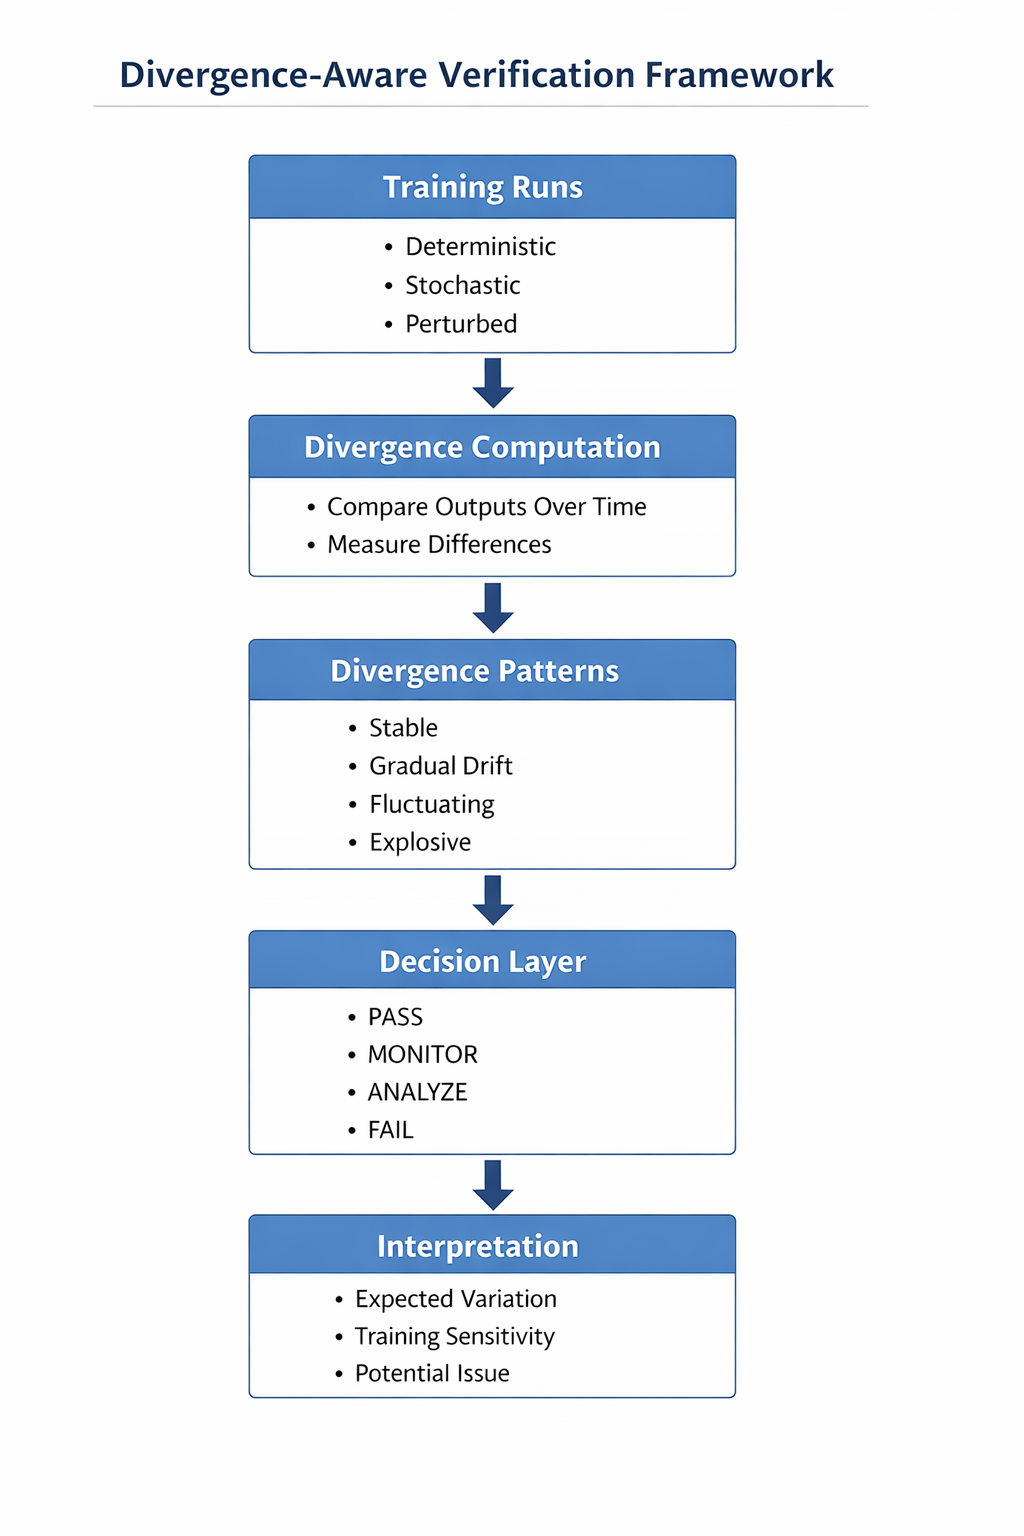

In [ ]:
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.use_deterministic_algorithms(True)

In [ ]:
#BIAS EXPERIMENT

text = [

    ("he", "doctor"),
    ("he", "doctor"),
    ("he", "engineer"),
    ("he", "scientist"),

    ("she", "nurse"),
    ("she", "nurse"),
    ("she", "teacher"),
    ("she", "caregiver"),


    ("he", "teacher"),
    ("she", "doctor"),
]

In [ ]:
words = [w for pair in text for w in pair]

vocab = list(set(words))
stoi = {w: i for i, w in enumerate(vocab)}
itos = {i: w for w, i in stoi.items()}

In [ ]:
X = [stoi[w1] for w1, w2 in text]
Y = [stoi[w2] for w1, w2 in text]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [ ]:
class TinyModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, 32)
        self.fc = nn.Linear(32, vocab_size)

    def forward(self, x):
        x = self.embed(x)
        return self.fc(x)

model = TinyModel(len(vocab))

In [ ]:
def compute_bias(model):
    model.eval()


    p_he_doc = get_prob(model, "he", "doctor")
    p_she_doc = get_prob(model, "she", "doctor")

    p_he_nurse = get_prob(model, "he", "nurse")
    p_she_nurse = get_prob(model, "she", "nurse")


    diff = (p_he_doc - p_she_doc) + (p_she_nurse - p_he_nurse)

    return diff

In [ ]:
def train_deterministic(X, Y, vocab_size):

    set_seed(42)

    model = TinyModel(vocab_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    loss_fn = torch.nn.CrossEntropyLoss()

    checkpoints = [500, 1000, 2000, 3500, 5000]
    diffs = []

    for step in range(5001):


        for i in range(0, len(X), 16):
            x_batch = X[i:i+16]
            y_batch = Y[i:i+16]

            logits = model(x_batch)
            loss = loss_fn(logits, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if step in checkpoints:
            diff = compute_bias(model)
            diffs.append(diff)

    return checkpoints, diffs

In [ ]:
def train_stochastic(X, Y, vocab_size):

    model = TinyModel(vocab_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    loss_fn = torch.nn.CrossEntropyLoss()

    checkpoints = [500, 1000, 2000, 3500, 5000]
    diffs = []

    for step in range(5001):


        idx = torch.randint(0, len(X), (16,))
        x_batch = X[idx]
        y_batch = Y[idx]

        logits = model(x_batch)
        loss = loss_fn(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step in checkpoints:
            diff = compute_bias(model)
            diffs.append(diff)

    return checkpoints, diffs

In [ ]:
def get_prob(model, word1, target):
    idx = torch.tensor([stoi[word1]])
    logits = model(idx)
    probs = torch.softmax(logits, dim=-1)
    return probs[0][stoi[target]].item()

In [ ]:
cp_det, diff_det = train_deterministic(X, Y, len(vocab))
cp_s1, diff_s1 = train_stochastic(X, Y, len(vocab))
cp_s2, diff_s2 = train_stochastic(X, Y, len(vocab))

In [ ]:
checkpoints = [500, 1000, 2000, 3500, 5000]

model = TinyModel(len(vocab))
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

for step in range(1, 5001):   # IMPORTANT: start from 1
    idx = torch.randint(0, len(X), (16,))
    x_batch = X[idx]
    y_batch = Y[idx]

    logits = model(x_batch)
    loss = loss_fn(logits, y_batch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step in checkpoints:
        torch.save(model.state_dict(), f"/content/checkpoint_{step}.pt")
        print(f"✅ Saved checkpoint at step {step}")

✅ Saved checkpoint at step 500
✅ Saved checkpoint at step 1000
✅ Saved checkpoint at step 2000
✅ Saved checkpoint at step 3500
✅ Saved checkpoint at step 5000


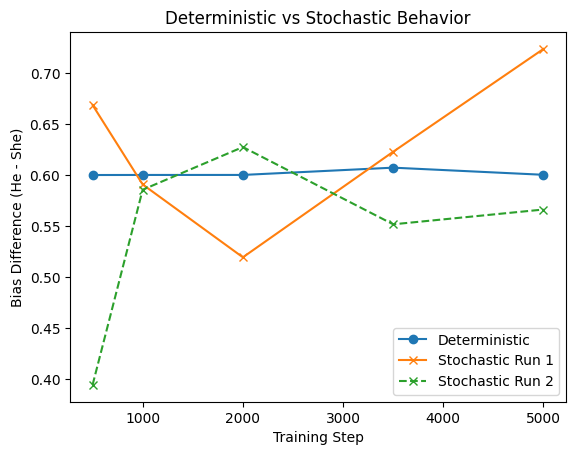

In [ ]:
plt.plot(cp_det, diff_det, marker='o', label="Deterministic")

plt.plot(cp_s1, diff_s1, marker='x', label="Stochastic Run 1")
plt.plot(cp_s2, diff_s2, marker='x', linestyle='--', label="Stochastic Run 2")

plt.xlabel("Training Step")
plt.ylabel("Bias Difference (He - She)")
plt.title("Deterministic vs Stochastic Behavior")

plt.legend()
plt.show()

In [ ]:
print("Final deterministic:", diff_det[-1])
print("Final stochastic run1:", diff_s1[-1])
print("Final stochastic run2:", diff_s2[-1])

Final deterministic: 0.6001313095302976
Final stochastic run1: 0.7233929468202405
Final stochastic run2: 0.5661342740640976


In [ ]:
# BEHAVIOR SENSITIVITY TEST

def perturb_model(model, scale=1e-3):
    new_model = TinyModel(len(vocab))
    new_model.load_state_dict(model.state_dict())

    with torch.no_grad():
        for param in new_model.parameters():
            param += scale * torch.randn_like(param)

    return new_model


base_model = TinyModel(len(vocab))
base_model.load_state_dict(torch.load("/content/checkpoint_5000.pt"))


perturbed_model = perturb_model(base_model, scale=1e-3)


base_bias = compute_bias(base_model)
perturbed_bias = compute_bias(perturbed_model)

print("Base bias:", base_bias)
print("Perturbed bias:", perturbed_bias)
print("Behavior difference:", abs(base_bias - perturbed_bias))

Base bias: 0.6392378967138939
Perturbed bias: 0.6401760214357637
Behavior difference: 0.0009381247218698263


In [ ]:
scales = [1e-4, 1e-3, 1e-2, 1e-1]

base_model = TinyModel(len(vocab))
base_model.load_state_dict(torch.load("/content/checkpoint_5000.pt"))

base_bias = compute_bias(base_model)

print("Base bias:", base_bias)
print("\n--- Sensitivity Test ---")

for scale in scales:
    perturbed_model = perturb_model(base_model, scale=scale)
    perturbed_bias = compute_bias(perturbed_model)
    diff = abs(base_bias - perturbed_bias)

    print(f"Scale {scale}: bias = {perturbed_bias:.4f}, diff = {diff:.4f}")

Base bias: 0.6392378967138939

--- Sensitivity Test ---
Scale 0.0001: bias = 0.6393, diff = 0.0001
Scale 0.001: bias = 0.6381, diff = 0.0012
Scale 0.01: bias = 0.6290, diff = 0.0102
Scale 0.1: bias = 0.6732, diff = 0.0340


In [ ]:
#REPRODUCIBILITY EXPERIMENT

In [ ]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

In [ ]:

text_repro = [
    ("he", "doctor"),
    ("he", "engineer"),
    ("she", "nurse"),
    ("she", "teacher"),
]

words_repro = [w for pair in text_repro for w in pair]

vocab_repro = list(set(words_repro))
stoi_repro = {w: i for i, w in enumerate(vocab_repro)}

X_repro = torch.tensor([stoi_repro[w1] for w1, w2 in text_repro])
Y_repro = torch.tensor([stoi_repro[w2] for w1, w2 in text_repro])

In [ ]:
def train_repro(X, Y, vocab_size, name):
    model = TinyModel(vocab_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    loss_fn = nn.CrossEntropyLoss()

    for step in range(2000):
        idx = torch.randint(0, len(X), (16,))
        x_batch = X[idx]
        y_batch = Y[idx]

        logits = model(x_batch)
        loss = loss_fn(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    torch.save(model.state_dict(), f"/content/{name}.pt")

In [ ]:
def compare_models(p1, p2):
    m1 = torch.load(p1)
    m2 = torch.load(p2)

    diff = 0
    for k in m1:
        diff += torch.sum((m1[k] - m2[k])**2).item()

    return diff

In [ ]:
#CASE A
set_seed(42)
train_repro(X_repro, Y_repro, len(vocab_repro), "run1")

set_seed(42)
train_repro(X_repro, Y_repro, len(vocab_repro), "run2")

print("Case A (same seed):", compare_models("/content/run1.pt", "/content/run2.pt"))

Case A (same seed): 0.0


In [ ]:
#CASE B
import random

shuffled = text_repro.copy()
random.shuffle(shuffled)

X_shuf = torch.tensor([stoi_repro[w1] for w1, w2 in shuffled])
Y_shuf = torch.tensor([stoi_repro[w2] for w1, w2 in shuffled])

set_seed(42)
train_repro(X_shuf, Y_shuf, len(vocab_repro), "run3")

print("Case B (shuffled):", compare_models("/content/run1.pt", "/content/run3.pt"))

Case B (shuffled): 0.29800416505895555


In [ ]:
# CASE C

modified = text_repro.copy()

modified[0] = ("he", "nurse")

X_mod = torch.tensor([stoi_repro[w1] for w1, w2 in modified])
Y_mod = torch.tensor([stoi_repro[w2] for w1, w2 in modified])

set_seed(42)
train_repro(X_mod, Y_mod, len(vocab_repro), "run4")

diff_C = compare_models("/content/run1.pt", "/content/run4.pt")

print("Case C: small data change → model differs", diff_C)

Case C: small data change → model differs 12.273059099912643


In [ ]:
print("Case A (same seed):", compare_models("/content/run1.pt", "/content/run2.pt"))

print("Case B (shuffled data):", compare_models("/content/run1.pt", "/content/run3.pt"))

print("Case C: small data change → model differs (qualitative)", diff_C)

Case A (same seed): 0.0
Case B (shuffled data): 0.29800416505895555
Case C: small data change → model differs (qualitative) 12.273059099912643


In [ ]:
import os
print(os.listdir("/content"))

['.config', 'checkpoint_2000.pt', 'run3.pt', 'run2.pt', 'run4.pt', 'checkpoint_3500.pt', 'checkpoint_1000.pt', 'run1.pt', 'checkpoint_5000.pt', 'checkpoint_500.pt', 'sample_data']


In [ ]:
#DIAGNOSTIC VERIFICATION TEST

In [ ]:
import hashlib

# Simple dataset (simulate training data)
data = [
    "he is a doctor",
    "she is a nurse",
    "he is an engineer",
    "she is a teacher",
    "he works in hospital",
    "she works in school"
]

In [ ]:
def chunk_data(data, chunk_size=2):
    return [data[i:i+chunk_size] for i in range(0, len(data), chunk_size)]

def hash_chunk(chunk):
    text = " ".join(chunk)
    return hashlib.sha256(text.encode()).hexdigest()

def compute_hashes(data):
    chunks = chunk_data(data)
    return [hash_chunk(chunk) for chunk in chunks]

In [ ]:
# Copy original
tampered_data = data.copy()

# Introduce small change (simulate bug / data issue)
tampered_data[3] = "she is doctor"  # changed from teacher → doctor

In [ ]:
hashes_original = compute_hashes(data)
hashes_tampered = compute_hashes(tampered_data)

if hashes_original == hashes_tampered:
    print("✅ Data matches")
else:
    print("❌ Data mismatch detected")

❌ Data mismatch detected


In [ ]:
def diagnostic_compare(data1, data2):
    chunks1 = chunk_data(data1)
    chunks2 = chunk_data(data2)

    for i, (c1, c2) in enumerate(zip(chunks1, chunks2)):
        h1 = hash_chunk(c1)
        h2 = hash_chunk(c2)

        if h1 != h2:
            print(f"\n❌ Mismatch at chunk {i}")
            print("Original chunk:", c1)
            print("Tampered chunk:", c2)

            # Go deeper (line-level)
            for j, (line1, line2) in enumerate(zip(c1, c2)):
                if line1 != line2:
                    print(f"  → Difference at line {j}")
                    print(f"     Original: {line1}")
                    print(f"     Tampered: {line2}")
            return

    print("✅ All chunks match")

diagnostic_compare(data, tampered_data)


❌ Mismatch at chunk 1
Original chunk: ['he is an engineer', 'she is a teacher']
Tampered chunk: ['he is an engineer', 'she is doctor']
  → Difference at line 1
     Original: she is a teacher
     Tampered: she is doctor


In [ ]:
def classify_failure(hashes1, hashes2):
    mismatches = [i for i, (h1, h2) in enumerate(zip(hashes1, hashes2)) if h1 != h2]

    if len(mismatches) == 0:
        return "No issue"

    elif len(mismatches) == 1:
        return "Localized data corruption"

    elif len(mismatches) > len(hashes1) * 0.8:
        return "Global change (tokenization or full data reorder)"

    else:
        return "Partial structural change (ordering or chunk boundary issue)"

In [ ]:
failure_type = classify_failure(hashes_original, hashes_tampered)

print("\nFailure Analysis")
print("-------------------")
print("Failure Type:", failure_type)
print("Mismatch Chunks:", [i for i, (h1, h2) in enumerate(zip(hashes_original, hashes_tampered)) if h1 != h2])


Failure Analysis
-------------------
Failure Type: Localized data corruption
Mismatch Chunks: [1]


In [ ]:
import random

shuffled_data = data.copy()
random.shuffle(shuffled_data)

hashes_shuffled = compute_hashes(shuffled_data)

print("\n--- Shuffled Scenario ---")
print("Failure Type:", classify_failure(hashes_original, hashes_shuffled))


--- Shuffled Scenario ---
Failure Type: Global change (tokenization or full data reorder)


In [ ]:
#DIVERGENCE OVER TIME

In [ ]:
import torch
import torch.nn as nn

def train_two_models(X, Y, vocab_size, optimizer_type="same", steps=5000):

    model_a = TinyModel(vocab_size)
    model_b = TinyModel(vocab_size)

    # Start identical
    model_b.load_state_dict(model_a.state_dict())

    # Optimizer selection
    if optimizer_type == "same":
        optimizer_a = torch.optim.Adam(model_a.parameters(), lr=0.01)
        optimizer_b = torch.optim.Adam(model_b.parameters(), lr=0.01)

    elif optimizer_type == "different":
        optimizer_a = torch.optim.Adam(model_a.parameters(), lr=0.01)
        optimizer_b = torch.optim.SGD(model_b.parameters(), lr=0.01)

    loss_fn = nn.CrossEntropyLoss()

    checkpoints = [500, 1000, 2000, 3500, 5000]
    diffs = []

    for step in range(1, steps + 1):

        # smaller batch (more sensitivity)
        idx = torch.randint(0, len(X), (4,))
        x_batch = X[idx]
        y_batch = Y[idx]

        # ---- Model A ----
        logits_a = model_a(x_batch)
        loss_a = loss_fn(logits_a, y_batch)

        optimizer_a.zero_grad()
        loss_a.backward()
        optimizer_a.step()

        # ---- Model B ----
        logits_b = model_b(x_batch)
        loss_b = loss_fn(logits_b, y_batch)

        optimizer_b.zero_grad()
        loss_b.backward()
        optimizer_b.step()

        # stronger + repeated perturbation
        if step in [100, 200, 300]:
            with torch.no_grad():
                for param in model_b.parameters():
                    param.add_(0.01 * torch.randn_like(param))

        # ---- Track divergence ----
        if step in checkpoints:
            bias_a = compute_bias(model_a)
            bias_b = compute_bias(model_b)

            diff = abs(bias_a - bias_b)
            diffs.append(diff)

            print(f"[{optimizer_type}] Step {step}: divergence = {diff:.4f}")

    return checkpoints, diffs

In [ ]:
# Adam vs Adam (baseline)
checkpoints, diffs_same = train_two_models(X, Y, len(vocab), optimizer_type="same")

print("\n-----------------------------\n")

# Adam vs SGD (comparison)
_, diffs_diff = train_two_models(X, Y, len(vocab), optimizer_type="different")

[same] Step 500: divergence = 0.0007
[same] Step 1000: divergence = 0.0004
[same] Step 2000: divergence = 0.0008
[same] Step 3500: divergence = 0.0010
[same] Step 5000: divergence = 0.0004

-----------------------------

[different] Step 500: divergence = 0.0386
[different] Step 1000: divergence = 0.0148
[different] Step 2000: divergence = 0.0541
[different] Step 3500: divergence = 0.0273
[different] Step 5000: divergence = 0.0364


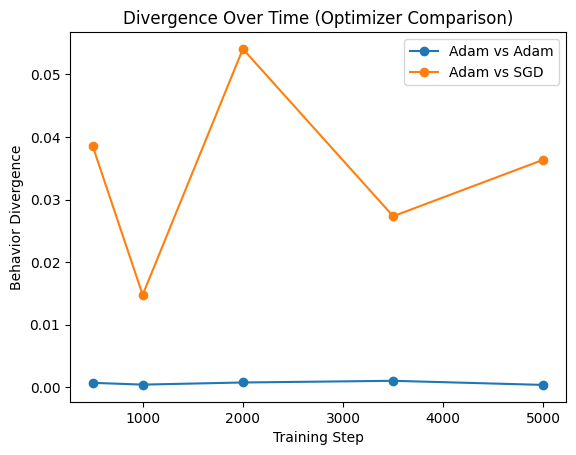

In [ ]:
import matplotlib.pyplot as plt

plt.plot(checkpoints, diffs_same, marker='o', label="Adam vs Adam")
plt.plot(checkpoints, diffs_diff, marker='o', label="Adam vs SGD")

plt.xlabel("Training Step")
plt.ylabel("Behavior Divergence")
plt.title("Divergence Over Time (Optimizer Comparison)")
plt.legend()
plt.show()

In [ ]:
import numpy as np

def classify_divergence(diff):
    diff = np.array(diff)

    max_div = np.max(diff)
    min_div = np.min(diff)
    jumps = np.diff(diff)

    variance = np.var(diff)

    if max_div - min_div < 0.01:
        return "stable"

    if np.max(jumps) > 0.1:
        return "explosive"

    if variance > 0.005:
        return "fluctuating"

    return "gradual_drift"


def divergence_decision(div_type):
    if div_type == "stable":
        return "PASS: consistent runs"

    elif div_type == "gradual_drift":
        return "MONITOR: gradual drift (likely optimizer / minor variation)"

    elif div_type == "explosive":
        return "FAIL: sharp divergence (potential issue)"

In [ ]:
print("---- Divergence Analysis ----")

runs = {
    "Deterministic": diff_det,
    "Stochastic Run 1": diff_s1,
    "Stochastic Run 2": diff_s2,
}

for name, diff in runs.items():
    div_type = classify_divergence(diff)
    decision = divergence_decision(div_type)

    print(f"\n{name}")
    print("Type:", div_type)
    print("Decision:", decision)

---- Divergence Analysis ----

Deterministic
Type: stable
Decision: PASS: consistent runs

Stochastic Run 1
Type: explosive
Decision: FAIL: sharp divergence (potential issue)

Stochastic Run 2
Type: explosive
Decision: FAIL: sharp divergence (potential issue)


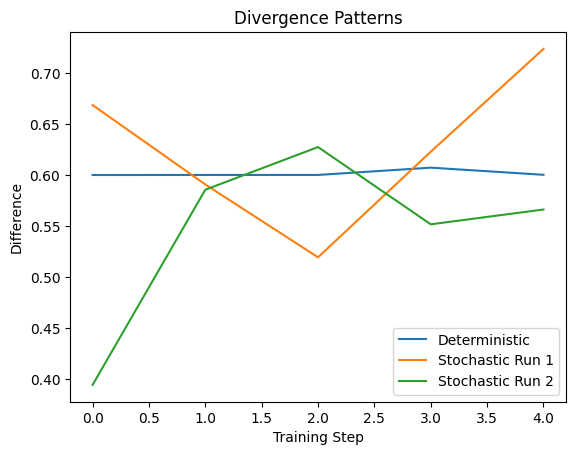

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

for name, diff in runs.items():
    plt.plot(diff, label=name)

plt.xlabel("Training Step")
plt.ylabel("Difference")
plt.title("Divergence Patterns")
plt.legend()
plt.show()

In [ ]:
print(classify_divergence(diff_det))
print(classify_divergence(diff_s1))
print(classify_divergence(diff_s2))

stable
explosive
explosive


In [ ]:
def divergence_decision(div_type):
    if div_type == "stable":
        return "PASS"

    elif div_type == "gradual_drift":
        return "MONITOR"

    elif div_type == "fluctuating":
        return "ANALYZE (non-monotonic divergence)"

    elif div_type == "explosive":
        return "FAIL"

In [ ]:
for name, diff in runs.items():
    div_type = classify_divergence(diff)
    decision = divergence_decision(div_type)

    print(f"{name}: {div_type} → {decision}")

Deterministic: stable → PASS
Stochastic Run 1: explosive → FAIL
Stochastic Run 2: explosive → FAIL
